In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## Task1

#### Task1.1

In [2]:
df = sns.load_dataset("iris")

print(df.head())
print(df.shape)
print(df.dtypes)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


- Dữ liệu có 150 dòng, 5 cột
- Các cột sepal_length, sepal_width, petal_length, petal_width có kiểu dữ liệu là float, còn cột species có kiểu dữ liệu là string (object) 

#### Task1.2

In [3]:
sepal_length = df["sepal_length"].to_numpy()
sepal_width = df["sepal_width"].to_numpy()
petal_length = df["petal_length"].to_numpy()
petal_width = df["petal_width"].to_numpy()
species = df["species"]


In [4]:
def tonghop(data, datastr):
    print("Mean:", np.mean(data))
    print("Median:", np.median(data))
    print("Mode:", df[datastr].mode().tolist())
    print("Var:", np.var(data))
    print("Std:", np.std(data))
    print("Min:", np.min(data))
    print("Max", np.max(data))
    q1, q2, q3 = np.percentile(data, [25, 50, 75])
    print("Q1, Q2, Q3:",q1, q2, q3)
    print("IQR:", q3 - q1)


In [5]:
print("sepal_length:")
tonghop(sepal_length, "sepal_length")

sepal_length:
Mean: 5.843333333333334
Median: 5.8
Mode: [5.0]
Var: 0.6811222222222223
Std: 0.8253012917851409
Min: 4.3
Max 7.9
Q1, Q2, Q3: 5.1 5.8 6.4
IQR: 1.3000000000000007


In [6]:
print("sepal_width:")
tonghop(sepal_width, "sepal_width")

sepal_width:
Mean: 3.0573333333333337
Median: 3.0
Mode: [3.0]
Var: 0.1887128888888889
Std: 0.4344109677354946
Min: 2.0
Max 4.4
Q1, Q2, Q3: 2.8 3.0 3.3
IQR: 0.5


In [7]:
print("petal_length:")
tonghop(petal_length, "petal_length")

petal_length:
Mean: 3.7580000000000005
Median: 4.35
Mode: [1.4, 1.5]
Var: 3.0955026666666665
Std: 1.759404065775303
Min: 1.0
Max 6.9
Q1, Q2, Q3: 1.6 4.35 5.1
IQR: 3.4999999999999996


In [8]:
print("petal_width:")
tonghop(petal_width, "petal_width")

petal_width:
Mean: 1.1993333333333336
Median: 1.3
Mode: [0.2]
Var: 0.5771328888888888
Std: 0.7596926279021594
Min: 0.1
Max 2.5
Q1, Q2, Q3: 0.3 1.3 1.8
IQR: 1.5


#### Task1.3

In [9]:
print("sepal_length")
stats = df.groupby("species")["sepal_length"].agg(["mean", "std"])
print(stats)
print()
print("sepal_width")
stats = df.groupby("species")["sepal_width"].agg(["mean", "std"])
print(stats)
print()
print("petal_length")
stats = df.groupby("species")["petal_length"].agg(["mean", "std"])
print(stats)
print()
print("petal_width")
stats = df.groupby("species")["petal_width"].agg(["mean", "std"])
print(stats)

sepal_length
             mean       std
species                    
setosa      5.006  0.352490
versicolor  5.936  0.516171
virginica   6.588  0.635880

sepal_width
             mean       std
species                    
setosa      3.428  0.379064
versicolor  2.770  0.313798
virginica   2.974  0.322497

petal_length
             mean       std
species                    
setosa      1.462  0.173664
versicolor  4.260  0.469911
virginica   5.552  0.551895

petal_width
             mean       std
species                    
setosa      0.246  0.105386
versicolor  1.326  0.197753
virginica   2.026  0.274650


Nhận xét:
Setosa là nhóm khác biệt nhất vì có petal_length và petal_width nhỏ hơn rất nhiều so với hai loài còn lại.

## Task2

#### Task2.1

In [10]:
def draw_hisplot(datastr):
    plt.figure(figsize = (6, 4))
    sns.histplot(df[datastr], kde = True)
    plt.title("Histogram + KDE của " + datastr)
    plt.xlabel(datastr)
    plt.ylabel("Số lượng")
    plt.show()

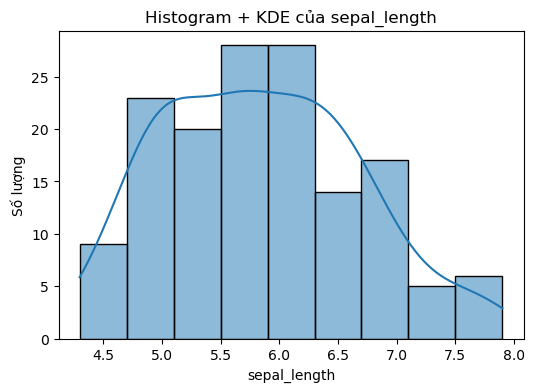

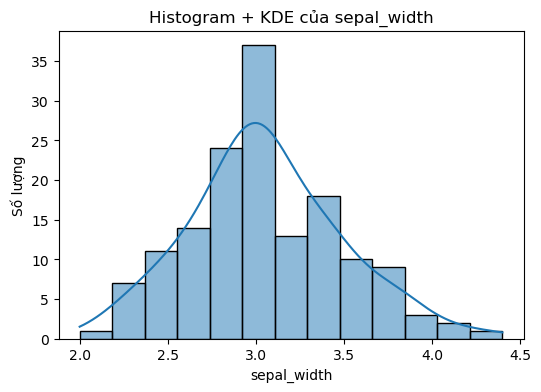

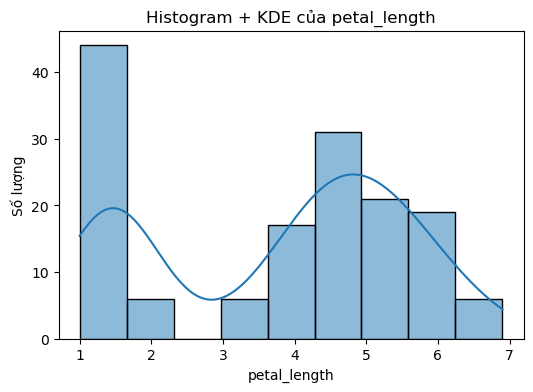

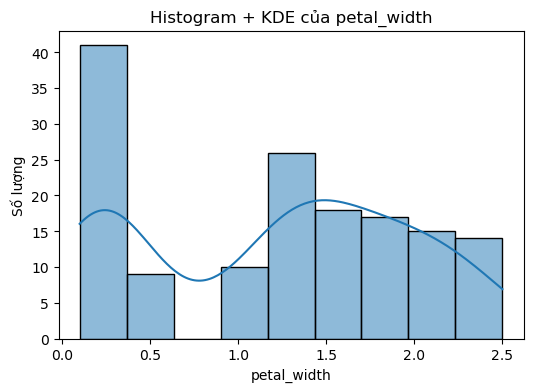

In [11]:
draw_hisplot("sepal_length")
draw_hisplot("sepal_width")
draw_hisplot("petal_length")
draw_hisplot("petal_width")

#### Task2.2

In [12]:
def draw_boxplot(datastr):
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="species", y=datastr, data=df)
    plt.title(datastr)
    plt.show()

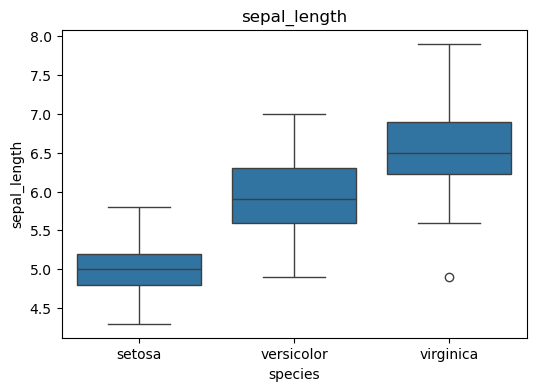

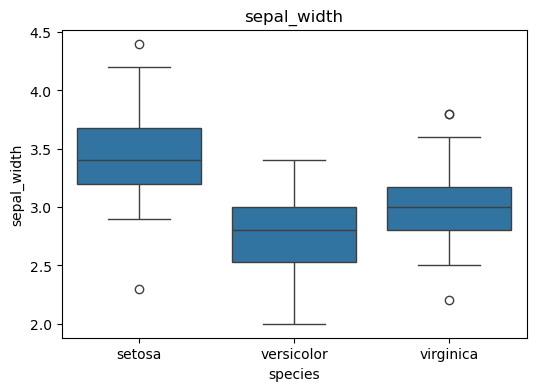

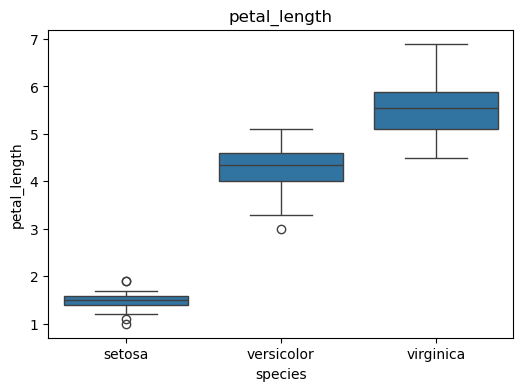

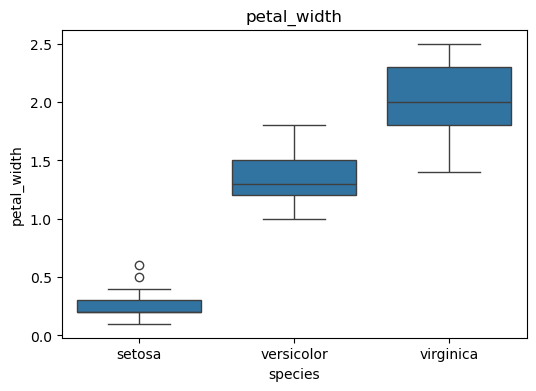

In [13]:
draw_boxplot("sepal_length")
draw_boxplot("sepal_width")
draw_boxplot("petal_length")
draw_boxplot("petal_width")

#### Task2.3

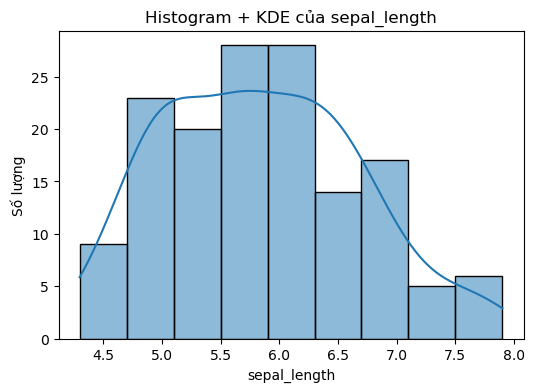

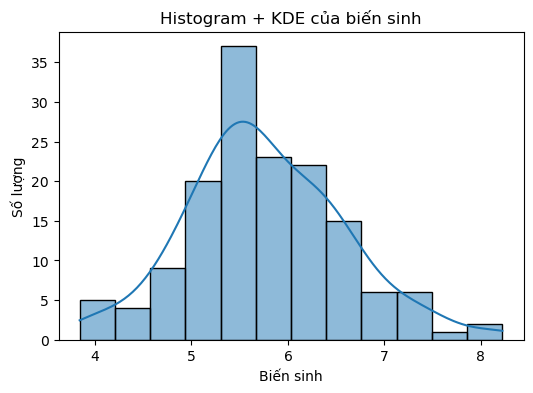

In [14]:
biensinh = np.random.normal(np.mean(sepal_length), np.std(sepal_length), sepal_length.size)
draw_hisplot("sepal_length")
plt.figure(figsize = (6, 4))
sns.histplot(biensinh, kde = True)
plt.title("Histogram + KDE của biến sinh")
plt.xlabel("Biến sinh")
plt.ylabel("Số lượng")
plt.show()

Nhận xét: không khớp nhau lắm

## Task3

#### Task3.1

In [15]:
features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
var = df[features].to_numpy()
print("Ma trận hiệp phương sai (covariance):")
cov = np.cov(var, rowvar = False)
print(cov)
print()
print("Ma trận tương quan (correlation):")
corr = np.corrcoef(var, rowvar = False)
print(corr)


Ma trận hiệp phương sai (covariance):
[[ 0.68569351 -0.042434    1.27431544  0.51627069]
 [-0.042434    0.18997942 -0.32965638 -0.12163937]
 [ 1.27431544 -0.32965638  3.11627785  1.2956094 ]
 [ 0.51627069 -0.12163937  1.2956094   0.58100626]]

Ma trận tương quan (correlation):
[[ 1.         -0.11756978  0.87175378  0.81794113]
 [-0.11756978  1.         -0.4284401  -0.36612593]
 [ 0.87175378 -0.4284401   1.          0.96286543]
 [ 0.81794113 -0.36612593  0.96286543  1.        ]]


#### Task3.2

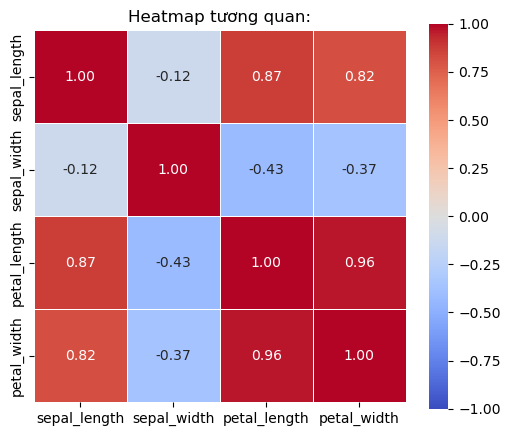

In [16]:
plt.figure(figsize=(6,5))
sns.heatmap(
    corr,
    annot = True,
    fmt=".2f",
    cmap="coolwarm",
    vmax=1,
    vmin=-1,
    xticklabels = features,
    yticklabels = features,
    square = True,
    linewidths = 0.5
)
plt.title("Heatmap tương quan:")
plt.show()

Nhận xét: Ta thấy có dấu hiệu đa cộng tuyến ở cặp petal_length và petal_width (có độ tương quan cao, xấp xỉ bằng 1)

#### Task3.3

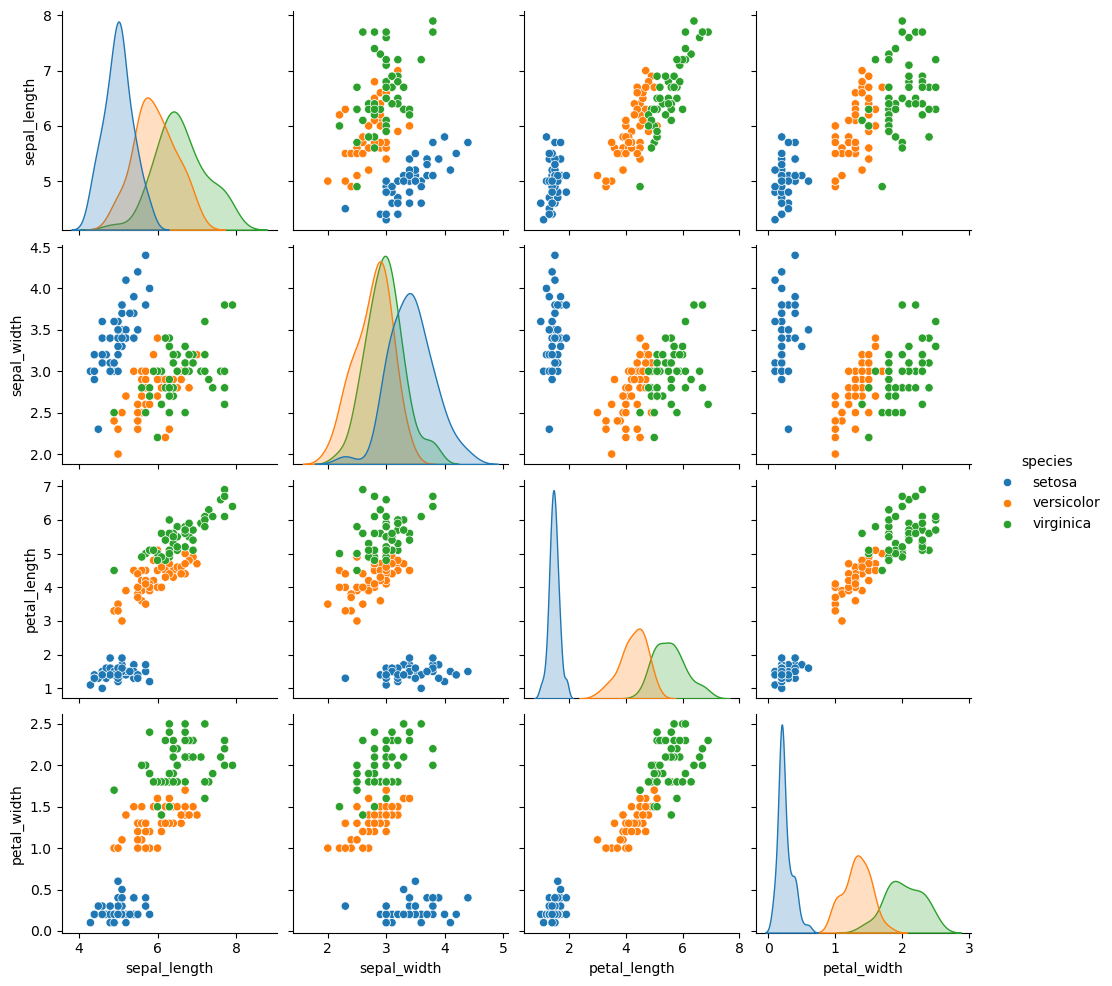

In [17]:
sns.pairplot(
    df, 
    vars = features,
    hue = "species",
    diag_kind = "kde"
)
plt.show()

Nhận xét:
 - petal_length và petal_width: tương quan dương mạnh, các điểm gần như nằm trên 1 đường thẳng tuyến tính
 - sepal_length và petal_length, petal_width: có xu hướng tương quan dương, nhưng không thẳng lắm
 - sepal_width và phần còn lại: gần như không liên quan đến nhau, các điểm phân tán rải rác, không có đặc điểm rõ ràng

## Task4

#### Task4.1

In [18]:
p_B = 0.1
p_pos_giveB = 0.95
p_pos_giveNB = 0.05

p_B_pos = (p_B * p_pos_giveB) / (p_B * p_pos_giveB + (1 - p_B)*p_pos_giveNB)
print(p_B_pos)

0.6785714285714285


#### Task4.2

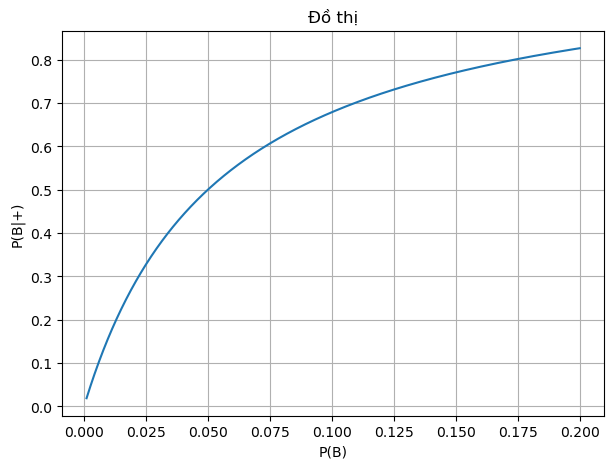

In [19]:
pB = np.linspace(0.001, 0.2, 1000)
p = (pB * p_pos_giveB) / (pB * p_pos_giveB + (1 - pB)*p_pos_giveNB)
plt.figure(figsize=(7, 5))
plt.plot(pB, p)
plt.xlabel("P(B)")
plt.ylabel("P(B|+)")
plt.title("Đồ thị")
plt.grid()
plt.show()

Phản trực giác: khi bênh hiếm P(B) thì dù test rất tốt, khi ra dương tính đa số vẫn không mắc bệnh

Lí do: Dương tính không nói bạn bị bệnh, nó chỉ nói bạn thuộc nhóm có nguy cơ, và nhóm này còn bị lẫn rất nhiều người không bệnh. Cho nên, dù tỷ lệ dương tính giả nhỏ, số ca dương tính giả vẫn áp đảo số ca dương tính thật, làm cho kết quả dương tính không đồng nghĩa với việc chắc chắn mắc bệnh.

#### Task4.3

In [20]:
dataset = [
    # Spam
    ("spam", "free money now"),
    ("spam", "win cash prize"),
    ("spam", "claim your free reward"),
    ("spam", "free gift for you"),
    ("spam", "limited time offer"),
    ("spam", "click here to claim prize"),
    ("spam", "congratulations you won lottery"),
    ("spam", "exclusive discount today"),
    ("spam", "earn money fast"),
    ("spam", "cheap loans available"),
    ("spam", "buy now limited offer"),
    ("spam", "urgent account verification"),
    ("spam", "claim bonus reward"),
    ("spam", "free vacation package"),
    ("spam", "winner collect cash now"),

    # Ham
    ("ham", "meeting at 2 pm"),
    ("ham", "project report completed"),
    ("ham", "see you tomorrow"),
    ("ham", "please send the document"),
    ("ham", "let us have lunch"),
    ("ham", "the meeting is cancelled"),
    ("ham", "can you review the report"),
    ("ham", "family dinner tonight"),
    ("ham", "happy birthday my friend"),
    ("ham", "please call me back"),
    ("ham", "the assignment is due tomorrow"),
    ("ham", "thank you for your help"),
    ("ham", "let us discuss the project"),
    ("ham", "see you at school"),
    ("ham", "meeting room has changed")
]

In [21]:
def text_classification(dataset, s):
    
    labels = []
    emails = []

    for label, email in dataset:
        if(label == "spam"):
            labels.append(1)
        else:
            labels.append(0)
        emails.append(email)

    vocab = []
    for email in emails:
        for word in email.split():
            if(word in vocab):
                continue
            vocab.append(word)

    def to_vector(s):
        res = np.zeros(len(vocab))
        for word in s.split():
            if word in vocab:
                res[vocab.index(word)] = 1
        return res

    x = np.array([to_vector(s) for s in emails])
    y = np.array(labels)

    input = to_vector(s)

    p_y = np.sum(y == 1)/len(y)

    p_x_givey = 1
    p_x_giveny = 1
    for i in range(len(input)):
        if input[i] == 1:
            p_x_givey *= (np.sum((x[:, i] == 1) & (y == 1)) + 1)/(np.sum(y == 1) + 2) #laplace smoothing
            p_x_giveny *= (np.sum((x[:, i] == 1) & (y == 0)) + 1)/(np.sum(y == 0) + 2)
        else:
            p_x_givey *= 1 - (np.sum((x[:, i] == 1) & (y == 1)) + 1)/(np.sum(y == 1) + 2) #laplace smoothing
            p_x_giveny *= 1 - (np.sum((x[:, i] == 1) & (y == 0)) + 1)/(np.sum(y == 0) + 2)

    p_y_x = (p_x_givey*p_y)/(p_x_givey*p_y + p_x_giveny*(1 - p_y))


    if(p_y_x > 0.5):
        return "spam"
    else:
        return "ham"

In [22]:
print(text_classification(dataset, "send the report"))

ham


In [23]:
test = ["free cash reward", "please review the project report", "free project meeting"]

for text in test:
    print(text,":",text_classification(dataset, text))

free cash reward : spam
please review the project report : ham
free project meeting : ham
